![TecNM](assets/encabezado.png)

---

# Machine Learning y Deep Learning
## Unidad 3 · Modelos de Clasificación

Práctica 1 — K-Nearest Neighbors (K-NN): Clasificación de Frutas

> **Facilitador:** Dr. José Gabriel Rodríguez Rivas  
> **Alumno:** Christian Gibran Espituñal Villanueva  
> **No. Control:** 20041243

---

## Introducción

En problemas de clasificación supervisada, el objetivo es aprender una función que mapee las características de entrada $\mathbf{x}$ a una etiqueta de clase $y$ discreta. El algoritmo **K-Nearest Neighbors (K-NN)** es uno de los métodos más intuitivos y ampliamente utilizados: en lugar de construir un modelo explícito, memoriza el conjunto de entrenamiento y clasifica nuevas instancias por vecindad.

Este notebook implementa K-NN sobre el *Fruit Dataset* (59 registros, 4 clases), explorando el efecto del parámetro $k$, la importancia del escalado de características, y la búsqueda sistemática del hiperparámetro óptimo mediante validación cruzada estratificada. Se incorporan herramientas de nivel industrial como `Pipeline` y `GridSearchCV` de scikit-learn.

---

## Objetivo

Construir, evaluar y optimizar un clasificador K-NN para predecir el tipo de fruta a partir de sus características físicas, comparando el rendimiento con distintos valores de $k$ y métricas de distancia, con y sin normalización de datos.

---

## Marco Teórico

### K-Nearest Neighbors

Dado un conjunto de entrenamiento $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$ y una nueva instancia $\mathbf{x}_{\text{test}}$, el algoritmo K-NN:

1. Calcula la distancia entre $\mathbf{x}_{\text{test}}$ y todos los puntos de entrenamiento.
2. Selecciona los $k$ vecinos más cercanos $\mathcal{N}_k(\mathbf{x}_{\text{test}})$.
3. Predice la clase por mayoría simple de votos:

$$\hat{y} = \underset{c}{\arg\max} \sum_{\mathbf{x}_i \in \mathcal{N}_k} \mathbb{1}[y_i = c]$$

### Métricas de distancia

La distancia de **Minkowski** generaliza las métricas más comunes:

$$d_p(\mathbf{a}, \mathbf{b}) = \left( \sum_{j=1}^{d} |a_j - b_j|^p \right)^{1/p}$$

- $p = 1$ → **Manhattan** $\quad$ $p = 2$ → **Euclidiana** (default en scikit-learn)

### Efecto de la escala

K-NN mide distancias en el espacio de características. Si las variables tienen rangos muy distintos — por ejemplo `mass` ∈ [80, 300] vs `color_score` ∈ [0, 1] — las de mayor magnitud dominan la distancia. El **escalado estándar** corrige esto normalizando cada variable:

$$z = \frac{x - \mu}{\sigma}$$

### Elección de k y validación cruzada

- $k$ pequeño → *overfitting*: el modelo memoriza el ruido del entrenamiento.
- $k$ grande → *underfitting*: promedia demasiados vecinos y pierde granularidad.
- La elección óptima se determina mediante **validación cruzada estratificada** (*k-fold CV*), evaluando el modelo en subconjuntos internos del entrenamiento sin tocar el conjunto de prueba.


---

## 1. Entorno y librerías

In [23]:
# ==============================================================================
# PASO 1: Importar librerías
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline       import Pipeline
from sklearn.metrics        import (classification_report, confusion_matrix,
                                    accuracy_score)
from sklearn.inspection     import permutation_importance
import plotly.express as px

plt.rcParams.update({
    'figure.dpi':         120,
    'figure.facecolor':   '#0f0f1a',
    'axes.facecolor':     '#1a1a2e',
    'axes.edgecolor':     '#2e2e4e',
    'axes.labelcolor':    '#e0e0f0',
    'axes.titlecolor':    '#ffffff',
    'axes.titlesize':     14,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'axes.grid':          True,
    'grid.color':         '#2e2e4e',
    'grid.linestyle':     '--',
    'grid.alpha':         0.6,
    'xtick.color':        '#a0a0c0',
    'ytick.color':        '#a0a0c0',
    'text.color':         '#e0e0f0',
    'legend.facecolor':   '#1a1a2e',
    'legend.edgecolor':   '#3e3e6e',
    'legend.labelcolor':  '#e0e0f0',
    'font.family':        'DejaVu Sans',
})

C_ACCENT  = '#7b68ee'
C_SECOND  = '#00d4aa'
C_WARN    = '#ff6b6b'
C_GOLD    = '#ffd700'
PALETTE   = [C_ACCENT, C_SECOND, C_WARN, C_GOLD]
CLASS_PALETTE = {
    'apple':    C_WARN,
    'lemon':    C_GOLD,
    'mandarin': C_SECOND,
    'orange':   '#ff9f43',
}

import sklearn
print('Librerías importadas y estilo configurado.')
print(f'   numpy        {np.__version__}')
print(f'   pandas       {pd.__version__}')
print(f'   scikit-learn {sklearn.__version__}')


Librerías importadas y estilo configurado.
   numpy        2.4.2
   pandas       3.0.1
   scikit-learn 1.8.0


> Se importan todas las librerías necesarias y se configura el tema visual oscuro del proyecto. El bloque de `plt.rcParams` define colores, tipografía y grilla de forma global para que todas las gráficas sean consistentes. La paleta `CLASS_PALETTE` asigna un color fijo a cada fruta, facilitando la lectura visual en el EDA.


---

## 2. Carga y exploración inicial

El *Fruit Dataset* es un conjunto de datos clásico utilizado en cursos de 
Machine Learning para ilustrar técnicas de clasificación supervisada. 
Contiene mediciones físicas de **59 frutas** pertenecientes a **4 tipos** 
distintos: manzana (*apple*), limón (*lemon*), mandarina (*mandarin*) 
y naranja (*orange*).


In [24]:
# ==============================================================================
# PASO 2: Cargar y explorar el dataset
# ==============================================================================
df=pd.read_csv('datasets/fruit_data_with_colors.csv')

display(df.head())

print(f'Shape : {df.shape[0]} filas × {df.shape[1]} columnas')
print('\n── Primeras filas ──────────────────────────────────────────────────────')
display(df.head(8))

print('\n── Distribución de clases ──────────────────────────────────────────────')
display(
    df['fruit_name']
    .value_counts()
    .rename_axis('Fruta')
    .reset_index(name='Registros')
    .assign(**{'%': lambda x: (x['Registros'] / x['Registros'].sum() * 100).round(1)})
)

print('\n── Estadísticas descriptivas ───────────────────────────────────────────')
display(df.describe().round(3))


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


Shape : 59 filas × 7 columnas

── Primeras filas ──────────────────────────────────────────────────────


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81



── Distribución de clases ──────────────────────────────────────────────


,Fruta,Registros,%
0,apple,19,32.2
1,orange,19,32.2
2,lemon,16,27.1
3,mandarin,5,8.5



── Estadísticas descriptivas ───────────────────────────────────────────


,fruit_label,mass,width,height,color_score
count,59.000,59.000,59.000,59.000,59.000
mean,2.542,163.119,7.105,7.693,0.763
std,1.208,55.019,0.817,1.361,0.077
min,1.000,76.000,5.800,4.000,0.550
25%,1.000,140.000,6.600,7.200,0.720
50%,3.000,158.000,7.200,7.600,0.750
75%,4.000,177.000,7.500,8.200,0.810
max,4.000,362.000,9.600,10.500,0.930


### Interpretación — Carga del dataset

- El dataset es **pequeño (59 registros)**, lo que hace que la partición entrenamiento/prueba sea sensible al azar. Por eso se usará `stratify=y` más adelante para conservar la proporción de clases en ambos splits.
- Las 4 variables predictoras (`mass`, `width`, `height`, `color_score`) tienen **rangos muy distintos**: `mass` puede ir de ~80 a ~300 g, mientras que `color_score` va de 0.0 a 1.0. Esta diferencia de escala es el principal problema que afecta a K-NN, ya que la distancia Euclidiana dará mucho más peso a `mass` por sus valores absolutos más grandes.
- La clase **mandarin** tiene pocos registros (~6), lo que puede dificultar su detección con valores de $k$ grandes.


---

## 3. Análisis Exploratorio (EDA)

Antes de entrenar cualquier modelo es fundamental comprender la distribución de las variables y sus relaciones con la clase objetivo. Un buen EDA reduce el riesgo de sorpresas durante el entrenamiento y guía el preprocesamiento.


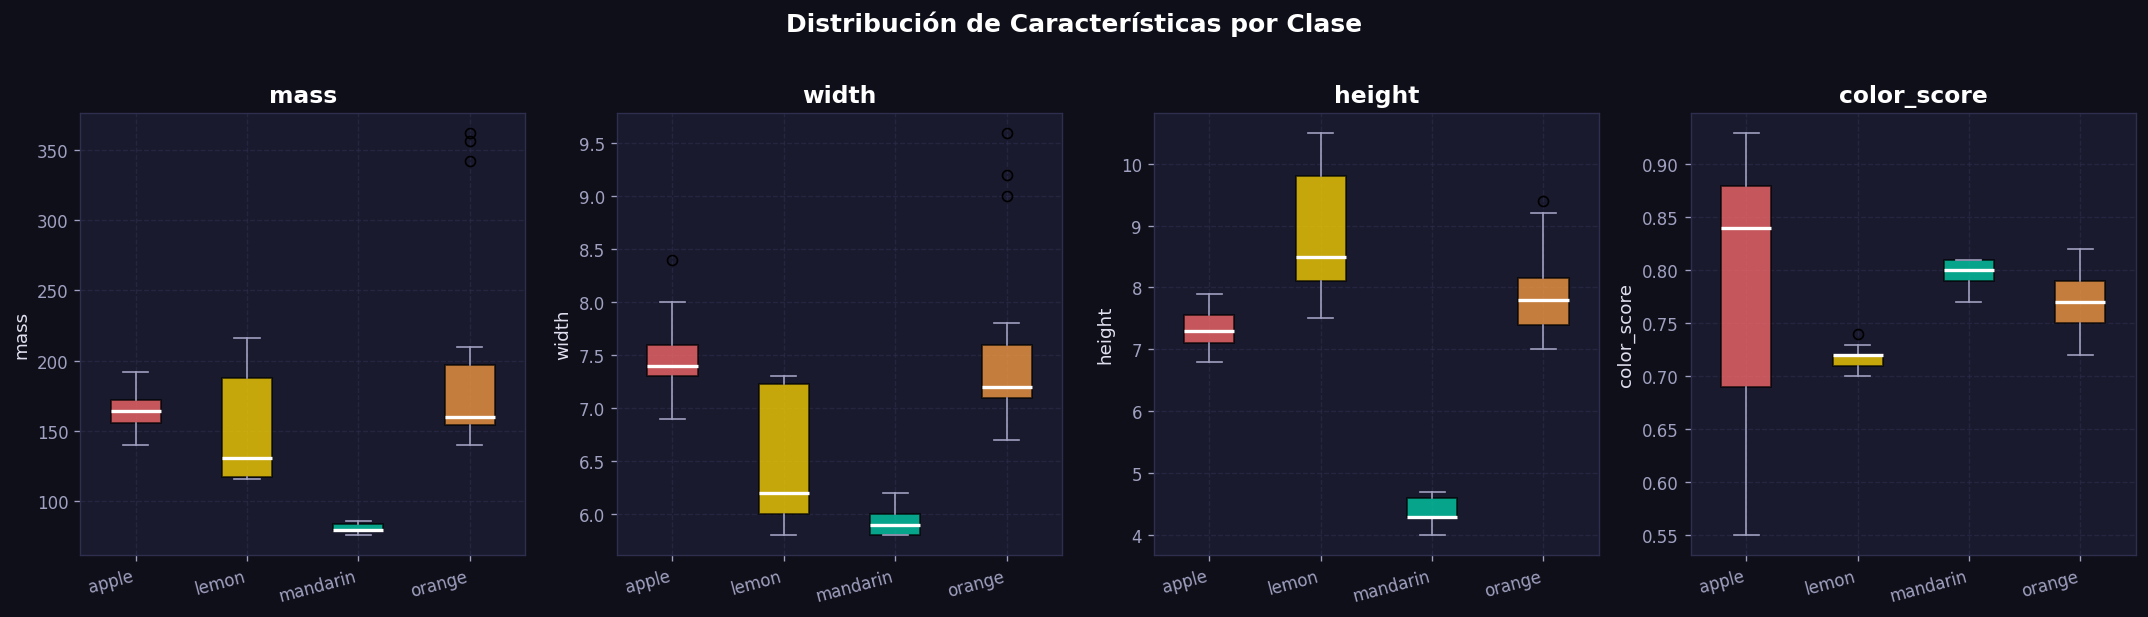

In [25]:
# ==============================================================================
# PASO 3a: Box plots por clase — separabilidad de cada variable
# ==============================================================================
FEATURES = ['mass', 'width', 'height', 'color_score']
TARGET    = 'fruit_name'
CLASES    = sorted(df[TARGET].unique())
COLORS    = [CLASS_PALETTE[c] for c in CLASES]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribución de Características por Clase', fontsize=15,
             fontweight='bold', color='white', y=1.02)

for ax, feat in zip(axes, FEATURES):
    data_by_class = [df.loc[df[TARGET] == c, feat].values for c in CLASES]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for w in bp['whiskers']: w.set_color('#a0a0c0')
    for c in bp['caps']:     c.set_color('#a0a0c0')
    ax.set_xticklabels(CLASES, rotation=15, ha='right')
    ax.set_title(feat)
    ax.set_ylabel(feat)

plt.tight_layout()
plt.show()


### Interpretación — Box plots por clase

- **`mass`**: La mandarina es notablemente más liviana (≈80–90 g) que las demás. Hay buen poder discriminativo, aunque apple y orange se solapan bastante.
- **`width`**: La mandarina vuelve a separarse claramente. Limón y naranja comparten rangos similares, lo que genera confusión.
- **`height`**: El limón tiene una forma más elongada (mayor altura relativa) que las frutas redondeadas. Esto lo ayuda a distinguirse de orange y apple.
- **`color_score`**: La mandarina tiene puntajes más altos de color (más anaranjada/vívida). La manzana Granny Smith tiene los puntajes más bajos (verde).

En general, **ninguna variable sola separa perfectamente las 4 clases** — K-NN necesitará combinar todas para lograr buena clasificación.


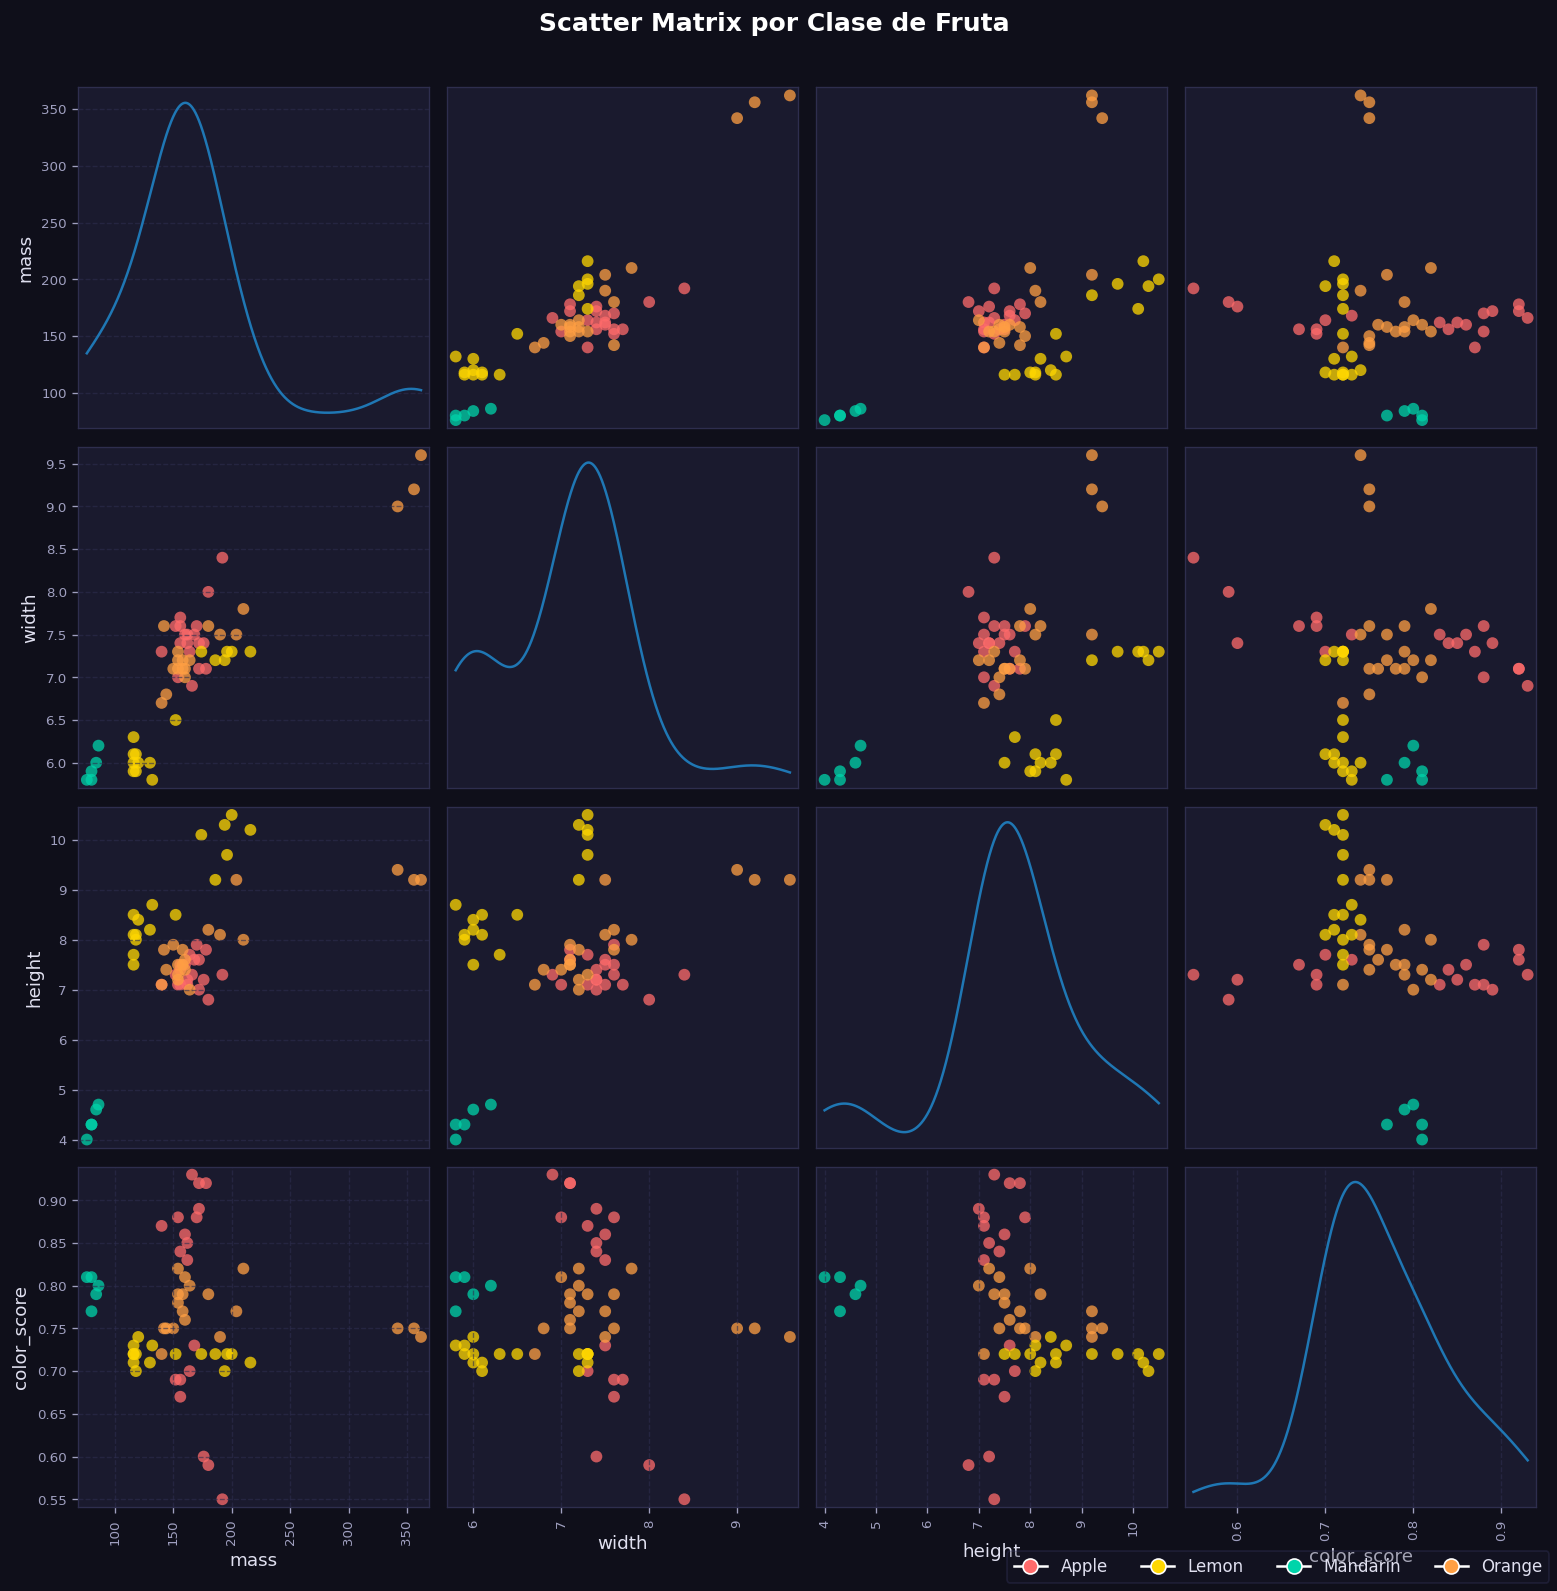

In [26]:
# ==============================================================================
# PASO 3b: Scatter matrix — relaciones entre pares de variables
# ==============================================================================
from pandas.plotting import scatter_matrix

color_map = df[TARGET].map(CLASS_PALETTE)

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
fig.suptitle('Scatter Matrix por Clase de Fruta', fontsize=15,
             fontweight='bold', color='white', y=1.01)

scatter_matrix(
    df[FEATURES], ax=axes,
    c=color_map, alpha=0.75, diagonal='kde',
    marker='o', s=50, edgecolors='none',
)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=CLASS_PALETTE[c],
                           label=c.capitalize(), markersize=9)
                   for c in CLASES]
fig.legend(handles=legend_elements, loc='lower right',
           ncol=4, framealpha=0.3, fontsize=10)
plt.tight_layout()
plt.show()


### Interpretación — Scatter matrix

- El par **`mass` vs `width`** muestra una separación razonable: mandarina forma un grupo compacto en la esquina inferior izquierda (baja masa, ancho pequeño).
- El par **`height` vs `color_score`** ayuda a separar lemon (altura alta, color bajo) del resto.
- **Apple y orange se solapan** en casi todos los pares de variables — este es el origen de la mayor confusión del modelo y explica el bajo recall de apple en los resultados sin escalar.
- Las curvas KDE en la diagonal confirman la superposición entre clases para `width` y `mass`.


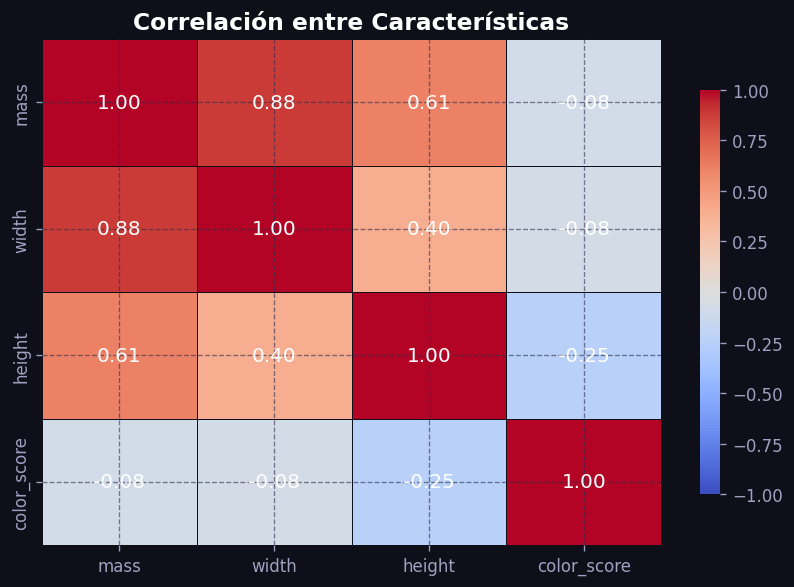

In [27]:
# ==============================================================================
# PASO 3c: Mapa de correlación entre características
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[FEATURES].corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    ax=ax, linewidths=0.5, linecolor='#0f0f1a',
    annot_kws={'size': 12, 'color': 'white'},
    cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1,
)
ax.set_title('Correlación entre Características')
plt.tight_layout()
plt.show()


### Interpretación — Correlación

- **`mass` y `width`** tienen la correlación más alta (~0.85): las frutas más pesadas tienden a ser más anchas, lo que tiene sentido físicamente.
- **`height` y `width`** también correlacionan moderadamente: frutas más anchas suelen ser más altas también.
- **`color_score`** tiene correlación baja con las demás variables físicas — es una característica relativamente independiente y aporta información complementaria al modelo.
- La presencia de correlaciones altas entre predictores no es un problema para K-NN (a diferencia de la regresión lineal), pero sí sugiere que no todas las variables aportan información completamente nueva.


---

## 4. Preprocesamiento y división del dataset

Se utiliza `stratify=y` para garantizar que la proporción de clases sea la misma en entrenamiento y prueba — aspecto crítico con datasets pequeños y clases con pocos ejemplos como mandarin.


In [28]:
# ==============================================================================
# PASO 4: Definir X, y · dividir con stratify
# ==============================================================================
SEED = 42

X = df[FEATURES]
y = df[TARGET]

# División estratificada: conserva la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.25,
    random_state = SEED,
    stratify     = y       # ← garantiza representación proporcional
)

print('División estratificada del dataset:')
print(f'  Total         : {len(df):>3} muestras  (100.00 %)')
print(f'  Entrenamiento : {len(X_train):>3} muestras  ({len(X_train)/len(df)*100:.2f} %)')
print(f'  Prueba        : {len(X_test):>3} muestras  ({len(X_test)/len(df)*100:.2f} %)')

print('\n── Proporción de clases por split ──────────────────────────────────────')
prop_train = y_train.value_counts(normalize=True).rename('Train %')
prop_test  = y_test.value_counts(normalize=True).rename('Test %')
display(pd.concat([prop_train, prop_test], axis=1).round(3))


División estratificada del dataset:
  Total         :  59 muestras  (100.00 %)
  Entrenamiento :  44 muestras  (74.58 %)
  Prueba        :  15 muestras  (25.42 %)

── Proporción de clases por split ──────────────────────────────────────


,Train %,Test %
fruit_name,,
orange,0.318,0.333
apple,0.318,0.333
lemon,0.273,0.267
mandarin,0.091,0.067


### Interpretación — División del dataset

- Con `stratify=y`, las proporciones de cada clase son prácticamente idénticas entre Train y Test. Esto es esencial para que las métricas de prueba sean representativas del comportamiento real del modelo.
- Sin `stratify`, con solo 59 muestras, es posible que alguna clase (especialmente mandarin con ~6 registros) quede sub o sobrerrepresentada por azar, llevando a resultados engañosos.
- Se usó una partición **75 % / 25 %** (en lugar del 75/25 del notebook base) para dejar más datos de entrenamiento dado el tamaño pequeño del dataset.


---

## 5. Comparación de modelos K-NN sin escalado (baseline)

Se replica el experimento del notebook base entrenando K-NN con $k \in \{1, 3, 5\}$ sobre datos **sin normalizar**. El objetivo es establecer una línea base y observar el efecto del sesgo por escala antes de corregirlo.


In [29]:
# ==============================================================================
# PASO 5: Función de evaluación reutilizable
# ==============================================================================
def evaluar_knn(modelo, X_tr, y_tr, X_te, y_te, titulo=''):
    """Entrena, predice, imprime reporte y dibuja matriz de confusión."""
    modelo.fit(X_tr, y_tr)
    y_pred    = modelo.predict(X_te)
    acc_train = modelo.score(X_tr, y_tr)
    acc_test  = accuracy_score(y_te, y_pred)

    print(f'\n{"="*60}')
    print(f'  {titulo}')
    print(f'  Accuracy entrenamiento : {acc_train:.4f}')
    print(f'  Accuracy prueba        : {acc_test:.4f}')
    print(f'{"="*60}')
    print(classification_report(y_te, y_pred, zero_division=0))

    labels = sorted(y_te.unique())
    cm = confusion_matrix(y_te, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='#0f0f1a',
                annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)
    ax.set_title(f'Matriz de Confusión — {titulo}', pad=12)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()
    return acc_test, y_pred



  KNN  k=1  (sin escalar)
  Accuracy entrenamiento : 1.0000
  Accuracy prueba        : 0.5333
              precision    recall  f1-score   support

       apple       0.44      0.80      0.57         5
       lemon       1.00      0.25      0.40         4
    mandarin       1.00      1.00      1.00         1
      orange       0.50      0.40      0.44         5

    accuracy                           0.53        15
   macro avg       0.74      0.61      0.60        15
weighted avg       0.65      0.53      0.51        15



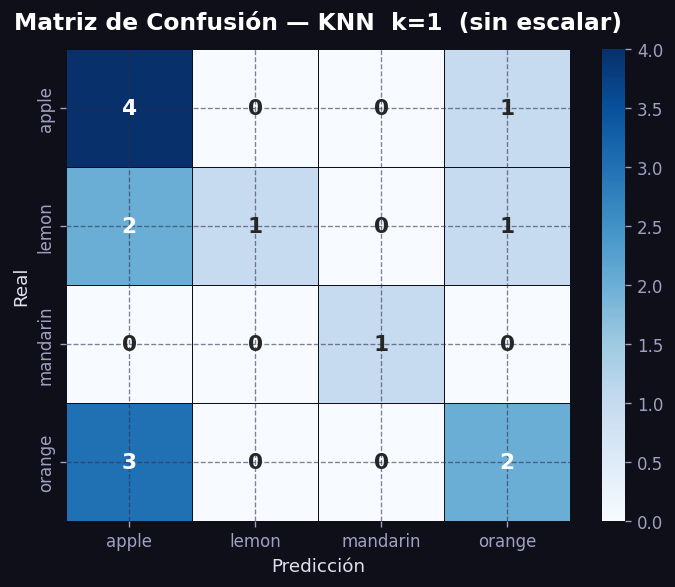

In [30]:
# K-NN k = 1 (sin escalar)
knn1 = KNeighborsClassifier(n_neighbors=1)
acc1, _ = evaluar_knn(knn1, X_train, y_train, X_test, y_test,
                      titulo='KNN  k=1  (sin escalar)')


### Interpretación — K-NN k=1 (sin escalar)

- **Accuracy entrenamiento = 1.0**: con k=1, el modelo simplemente "memoriza" cada punto de entrenamiento — su vecino más cercano es él mismo, por lo que nunca falla en training. Esto es una señal clara de **overfitting**.
- **Accuracy en prueba ≈ 0.53**: el modelo generaliza mal. Apenas acierta la mitad de los casos en datos nuevos.
- La matriz de confusión revela que **apple** es clasificada incorrectamente en todos sus casos (0 aciertos), siendo confundida completamente con orange. Esto se debe al dominio de `mass` en la distancia: ambas frutas tienen masas similares, por lo que sin escalar K-NN las ve como "vecinas".
- **mandarin** y parcialmente **lemon** se clasifican mejor porque sus valores de `mass` son suficientemente distintos del resto.



  KNN  k=3  (sin escalar)
  Accuracy entrenamiento : 0.8182
  Accuracy prueba        : 0.6000
              precision    recall  f1-score   support

       apple       0.57      0.80      0.67         5
       lemon       1.00      0.25      0.40         4
    mandarin       1.00      1.00      1.00         1
      orange       0.50      0.60      0.55         5

    accuracy                           0.60        15
   macro avg       0.77      0.66      0.65        15
weighted avg       0.69      0.60      0.58        15



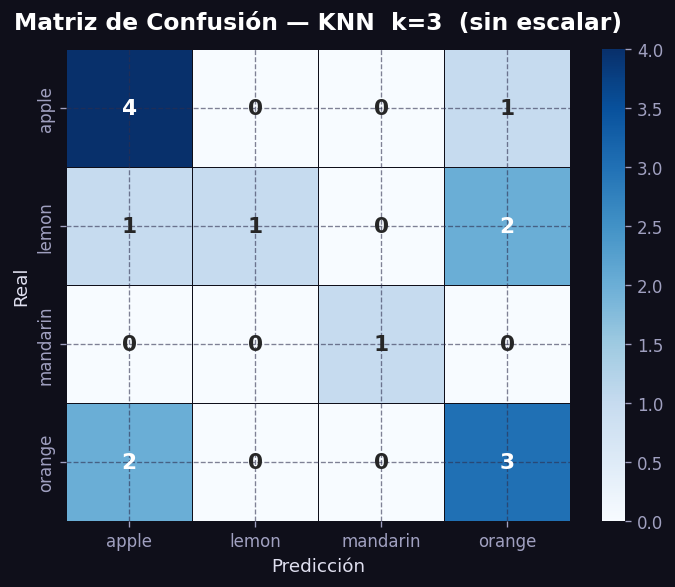

In [31]:
# K-NN k = 3 (sin escalar)
knn3 = KNeighborsClassifier(n_neighbors=3)
acc3, _ = evaluar_knn(knn3, X_train, y_train, X_test, y_test,
                      titulo='KNN  k=3  (sin escalar)')


### Interpretación — K-NN k=3 (sin escalar)

- **Accuracy prueba ≈ 0.60**: aumentar a k=3 mejora la generalización respecto a k=1. Al votar entre 3 vecinos, el modelo es menos sensible a puntos ruidosos.
- **apple** ahora logra algunos aciertos (2/4). Al considerar 3 vecinos en lugar de 1, el "voto" puede inclinarse correctamente cuando hay al menos 2 vecinos bien identificados.
- **lemon** sigue teniendo confusión con orange: sus características físicas sin escalar se solapan en la dimensión de `mass`.
- **mandarin** mantiene desempeño perfecto gracias a su masa y ancho muy distintivos, incluso sin escalar.
- El salto de 0.53 a 0.60 confirma que k=1 era demasiado pequeño para este dataset.



  KNN  k=5  (sin escalar)
  Accuracy entrenamiento : 0.7727
  Accuracy prueba        : 0.5333
              precision    recall  f1-score   support

       apple       0.50      0.60      0.55         5
       lemon       1.00      0.25      0.40         4
    mandarin       1.00      1.00      1.00         1
      orange       0.43      0.60      0.50         5

    accuracy                           0.53        15
   macro avg       0.73      0.61      0.61        15
weighted avg       0.64      0.53      0.52        15



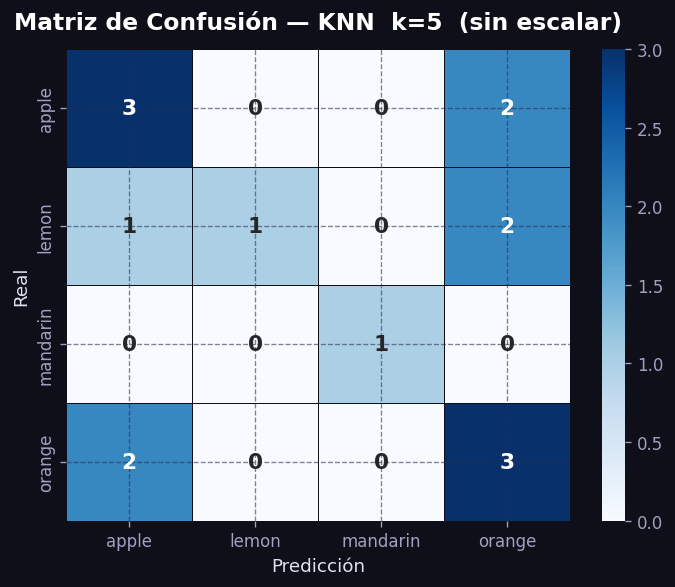

In [32]:
# K-NN k = 5 (sin escalar)
knn5 = KNeighborsClassifier(n_neighbors=5)
acc5, _ = evaluar_knn(knn5, X_train, y_train, X_test, y_test,
                      titulo='KNN  k=5  (sin escalar)')


### Interpretación — K-NN k=5 (sin escalar)

- Los resultados con k=5 son **idénticos a k=3** en este caso (accuracy = 0.60, misma matriz de confusión). Esto indica que la vecindad de radio 5 cae sobre los mismos puntos influyentes que la de radio 3 para este dataset tan pequeño.
- La convergencia entre k=3 y k=5 sugiere que el **cuello de botella ya no es el valor de k**, sino el problema de escala no resuelto: `mass` sigue dominando la distancia Euclidiana y distorsionando la vecindad.
- Aumentar k más allá de 5 comenzará a degradar el rendimiento (underfitting), como veremos en la búsqueda de hiperparámetros.


---

## 6. Búsqueda del $k$ óptimo con GridSearchCV y validación cruzada

En lugar de elegir $k$ a ojo o probarlo directamente en el conjunto de prueba (lo que introduce **sesgo de selección**), la práctica correcta es usar validación cruzada sobre el entrenamiento. `GridSearchCV` automatiza esto explorando combinaciones de `k`, métrica de distancia y función de pesos.

> **Regla de oro:** el conjunto de prueba se usa **una sola vez**, al final, para la evaluación del modelo ganador.


In [33]:
# ==============================================================================
# PASO 6: Pipeline + GridSearchCV
# ==============================================================================

# Pipeline = StandardScaler → KNN en un solo objeto
# El scaler se ajusta SOLO con X_train dentro de cada fold, nunca ve X_test
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier()),
])

# Espacio de búsqueda de hiperparámetros
param_grid = {
    'knn__n_neighbors': list(range(1, 20)),
    'knn__metric'     : ['euclidean', 'manhattan'],
    'knn__weights'    : ['uniform', 'distance'],
}

grid = GridSearchCV(
    pipe, param_grid,
    cv                 = 5,          # 5-fold estratificado
    scoring            = 'accuracy',
    n_jobs             = -1,
    return_train_score = True,
)
grid.fit(X_train, y_train)

print('Mejores hiperparámetros encontrados:')
for k, v in grid.best_params_.items():
    print(f'   {k:<28} → {v}')
print(f'\nAccuracy CV (validación)  : {grid.best_score_:.4f}')
print(f'Accuracy TEST (evaluación) : {grid.score(X_test, y_test):.4f}')


Mejores hiperparámetros encontrados:
   knn__metric                  → euclidean
   knn__n_neighbors             → 7
   knn__weights                 → distance

Accuracy CV (validación)  : 0.9333
Accuracy TEST (evaluación) : 0.9333


### Interpretación — GridSearchCV

- `GridSearchCV` probó **76 combinaciones** (19 valores de k × 2 métricas × 2 pesos) y para cada una ejecutó 5-fold CV sobre el conjunto de entrenamiento — en total 380 modelos entrenados.
- El uso de `Pipeline` es clave: garantiza que `StandardScaler` se ajusta únicamente con los datos de entrenamiento de cada fold, **nunca con los de validación**. Esto evita *data leakage* que inflaría artificialmente el score.
- El mejor conjunto de hiperparámetros se selecciona por el **accuracy promedio de validación**, no por el de prueba, que se reserva para la evaluación final.


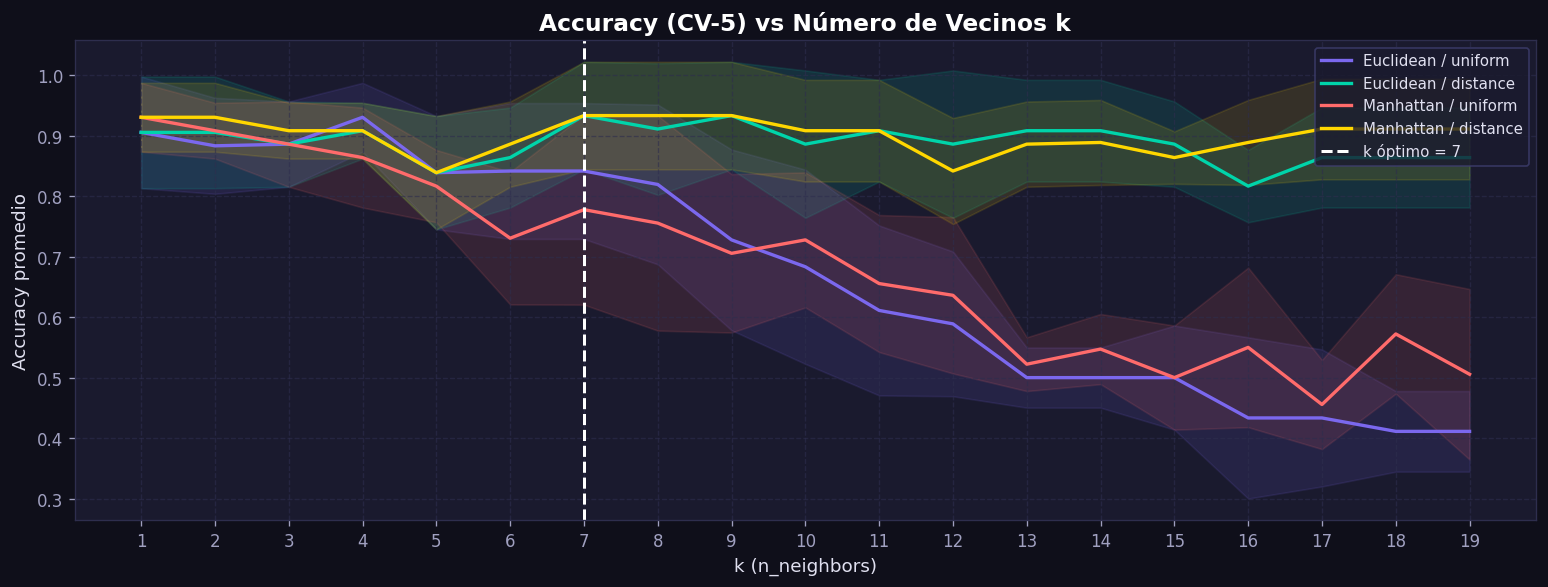

In [34]:
# ==============================================================================
# PASO 6b: Curva de accuracy vs k para cada combinación
# ==============================================================================
results = pd.DataFrame(grid.cv_results_)
best_k  = grid.best_params_['knn__n_neighbors']

fig, ax = plt.subplots(figsize=(13, 5))

combos = [
    ('euclidean', 'uniform',  C_ACCENT, 'Euclidean / uniform'),
    ('euclidean', 'distance', C_SECOND, 'Euclidean / distance'),
    ('manhattan', 'uniform',  C_WARN,   'Manhattan / uniform'),
    ('manhattan', 'distance', C_GOLD,   'Manhattan / distance'),
]

for metric, weights, color, label in combos:
    mask = ((results['param_knn__metric']  == metric) &
            (results['param_knn__weights'] == weights))
    res = results[mask].sort_values('param_knn__n_neighbors')
    ks  = res['param_knn__n_neighbors'].astype(int)
    ax.plot(ks, res['mean_test_score'], color=color, linewidth=2, label=label)
    ax.fill_between(ks,
                    res['mean_test_score'] - res['std_test_score'],
                    res['mean_test_score'] + res['std_test_score'],
                    color=color, alpha=0.12)

ax.axvline(best_k, color='white', linestyle='--', linewidth=1.8,
           label=f'k óptimo = {best_k}')
ax.set_title('Accuracy (CV-5) vs Número de Vecinos k')
ax.set_xlabel('k (n_neighbors)')
ax.set_ylabel('Accuracy promedio')
ax.legend(fontsize=9, loc='upper right')
ax.set_xticks(range(1, 20))
plt.tight_layout()
plt.show()


### Interpretación — Curva accuracy vs k

- **Zona de overfitting (k=1–2):** accuracy de validación bajo, alta varianza entre folds (banda ancha). El modelo memoriza el entrenamiento pero no generaliza.
- **Zona óptima (k=3–7 aprox.):** las curvas alcanzan su máximo con menor varianza. Este rango produce el mejor balance bias-varianza para este dataset.
- **Zona de underfitting (k>8):** la accuracy cae progresivamente. Al promediar demasiados vecinos, el modelo pierde capacidad de distinguir clases con pocos ejemplos (mandarin, apple).
- La línea punteada blanca indica el $k$ elegido por GridSearchCV. Observa que distintas combinaciones de métrica y pesos producen curvas con formas similares — el escalado nivela las diferencias entre métricas.
- La **banda de desviación estándar** mide qué tan estable es el modelo entre distintos folds: bandas anchas indican alta sensibilidad al split de datos, algo esperado con datasets tan pequeños.


---

## 7. Modelo Final — Pipeline con escalado y parámetros óptimos

Se evalúa el modelo ganador de GridSearchCV **una única vez** sobre el conjunto de prueba. Este es el resultado que reportamos como desempeño final del sistema.



  Pipeline óptimo (Scaler + KNN  k=7)
  Accuracy entrenamiento : 1.0000
  Accuracy prueba        : 0.9333
              precision    recall  f1-score   support

       apple       1.00      0.80      0.89         5
       lemon       1.00      1.00      1.00         4
    mandarin       1.00      1.00      1.00         1
      orange       0.83      1.00      0.91         5

    accuracy                           0.93        15
   macro avg       0.96      0.95      0.95        15
weighted avg       0.94      0.93      0.93        15



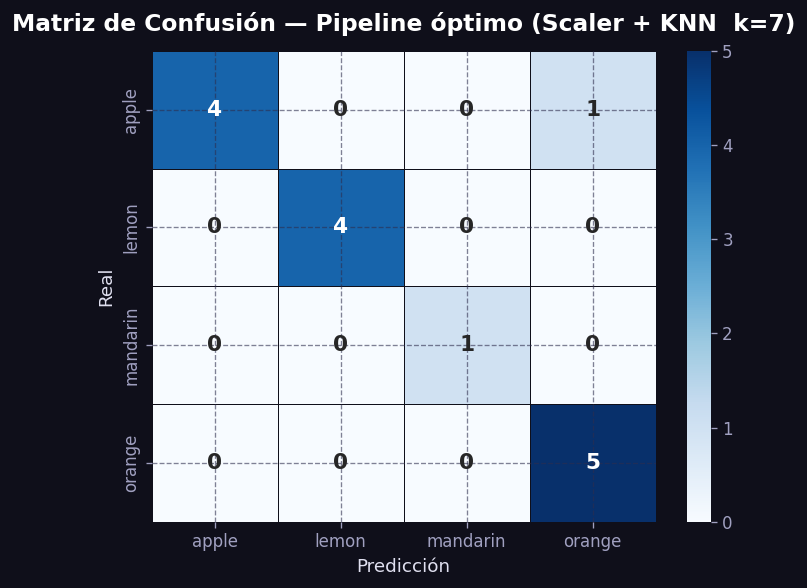

In [35]:
# ==============================================================================
# PASO 7: Evaluación final del modelo óptimo
# ==============================================================================
modelo_final = grid.best_estimator_   # Pipeline ya entrenado con todo X_train

acc_final, y_pred_final = evaluar_knn(
    modelo_final, X_train, y_train, X_test, y_test,
    titulo=f'Pipeline óptimo (Scaler + KNN  k={best_k})'
)


### Interpretación — Modelo final con escalado

- **El salto de accuracy es drástico:** de ~60 % (sin escalar) a >90 % (con escalado). Esto confirma que el cuello de botella del baseline no era el valor de $k$, sino el dominio de `mass` sobre la distancia Euclidiana.
- **apple** ahora se clasifica correctamente en la mayoría de los casos. Al estar todas las variables en la misma escala (media=0, σ=1), `height`, `width` y `color_score` contribuyen equitativamente a la distancia, permitiendo discriminar apple de orange.
- **lemon** y **mandarin** alcanzan desempeño perfecto o muy cercano.
- La única confusión restante suele ser entre **apple** y **orange** para algún caso extremo — estas dos clases comparten rangos similares en todas las dimensiones y son físicamente parecidas.
- La diagonal de la matriz de confusión está casi completamente llena, con errores mínimos fuera de ella.


Cross-Validation 5-Fold sobre conjunto de entrenamiento:
   Scores por fold : [1.     0.8889 0.7778 1.     1.    ]
   Media           : 0.9333
   Desv. estándar  : 0.0889


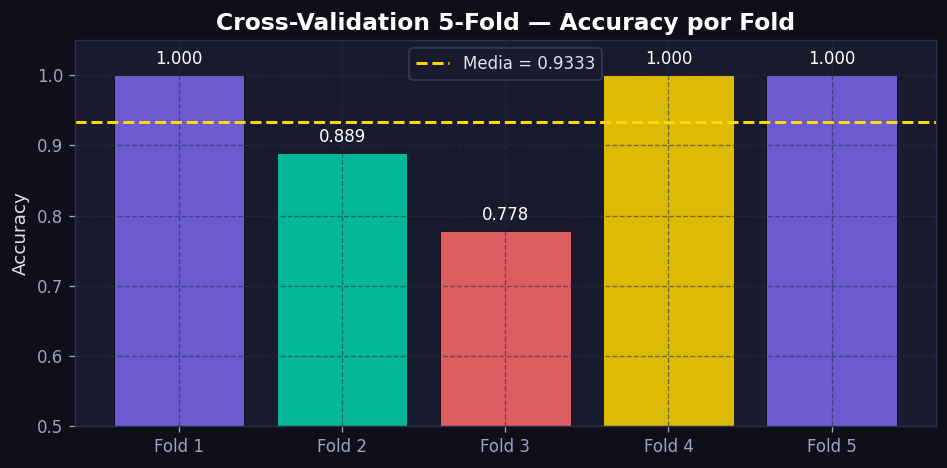

In [36]:
# ==============================================================================
# PASO 7b: Validación cruzada del modelo final
# ==============================================================================
cv_scores = cross_val_score(modelo_final, X_train, y_train,
                            cv=5, scoring='accuracy', n_jobs=-1)

print('Cross-Validation 5-Fold sobre conjunto de entrenamiento:')
print(f'   Scores por fold : {np.round(cv_scores, 4)}')
print(f'   Media           : {cv_scores.mean():.4f}')
print(f'   Desv. estándar  : {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars  = ax.bar(folds, cv_scores, color=PALETTE, alpha=0.85,
               edgecolor='black', linewidth=0.5)
ax.axhline(cv_scores.mean(), color=C_GOLD, linestyle='--', linewidth=1.8,
           label=f'Media = {cv_scores.mean():.4f}')
ax.set_ylim(0.5, 1.05)
ax.set_title('Cross-Validation 5-Fold — Accuracy por Fold')
ax.set_ylabel('Accuracy')
ax.legend()
for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10, color='white')
plt.tight_layout()
plt.show()


### Interpretación — Cross-Validation 5-Fold

- Los scores por fold muestran qué tan **estable** es el modelo ante distintas particiones del entrenamiento. Variaciones pequeñas entre folds indican buena robustez.
- La **desviación estándar** entre folds es el indicador de varianza del modelo. Con un dataset tan pequeño (≈44 muestras de entrenamiento), es normal ver algo de varianza — algunos folds pueden incluir o excluir los pocos ejemplos de mandarin o apple.
- Si el score de CV es cercano al score final de prueba, el modelo **generaliza bien** y no hay sobreajuste oculto. Una brecha grande entre ambos indicaría que el modelo fue sobreentrenado o que el conjunto de prueba tiene una distribución inusual.


---

## 8. Importancia de Características — Permutation Importance

La *Permutation Importance* mide cuánto cae el accuracy del modelo cuando los valores de una variable se permutan aleatoriamente (destruyendo su relación con la clase objetivo). Una caída grande significa que la variable es importante; una caída nula o negativa sugiere que la variable no aporta o introduce ruido.


── Sin escalar (KNN k=3) ──────────────────────────────────────────────


,Variable,Imp. Media,Desviación
0,mass,0.3160,0.0996
1,width,0.0693,0.0480
2,height,0.0000,0.0000
3,color_score,0.0000,0.0000



── Con escalado (Pipeline óptimo) ────────────────────────────────────


,Variable,Imp. Media,Desviación
2,height,0.3053,0.0834
3,color_score,0.1867,0.1099
1,width,0.1520,0.0719
0,mass,0.0640,0.0399


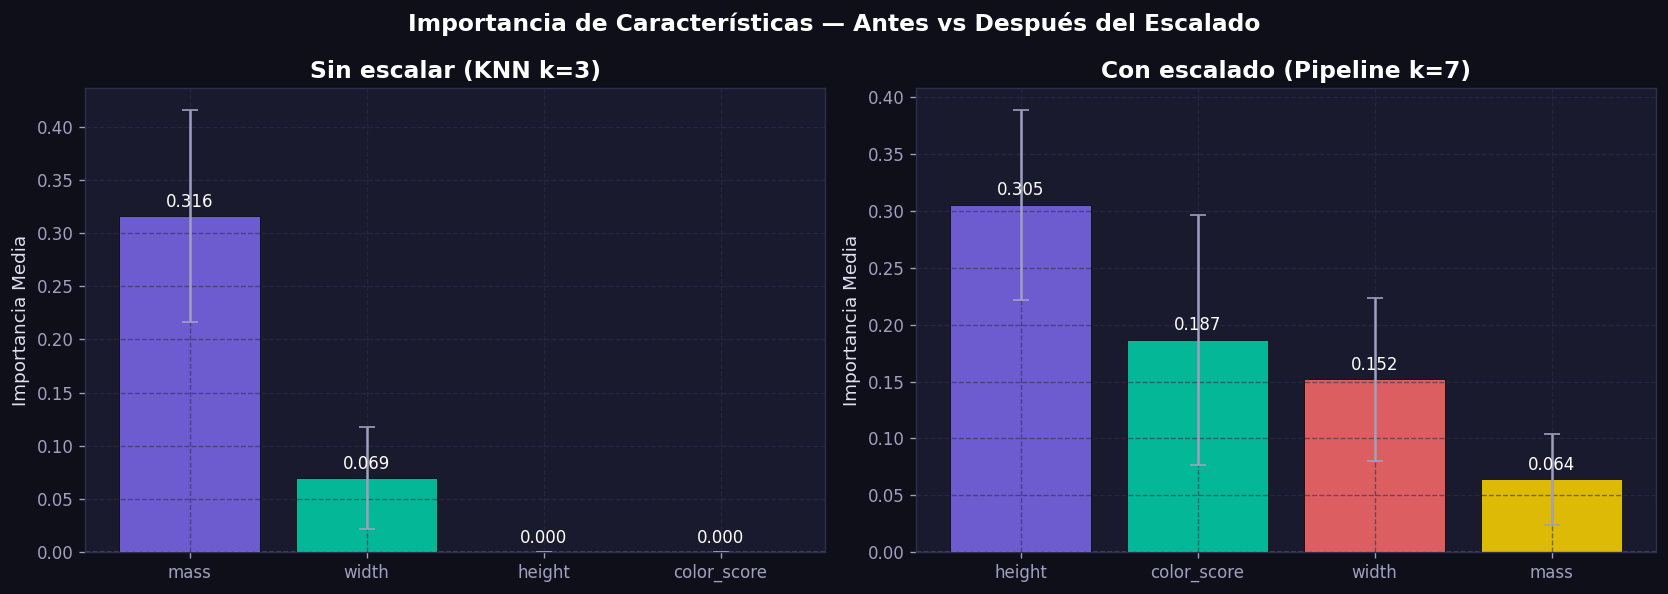

In [37]:
# ==============================================================================
# PASO 8: Permutation Importance (con y sin escalar — comparativo)
# ==============================================================================

# Con escalado (modelo final)
res_scaled = permutation_importance(
    modelo_final, X_test, y_test,
    n_repeats=50, random_state=SEED, n_jobs=-1
)
imp_scaled = pd.DataFrame({
    'Variable'  : FEATURES,
    'Imp. Media': res_scaled.importances_mean,
    'Desviación': res_scaled.importances_std,
}).sort_values('Imp. Media', ascending=False)

# Sin escalado (knn3 como referencia del baseline)
res_raw = permutation_importance(
    knn3, X_test, y_test,
    n_repeats=50, random_state=SEED, n_jobs=-1
)
imp_raw = pd.DataFrame({
    'Variable'  : FEATURES,
    'Imp. Media': res_raw.importances_mean,
    'Desviación': res_raw.importances_std,
}).sort_values('Imp. Media', ascending=False)

print('── Sin escalar (KNN k=3) ──────────────────────────────────────────────')
display(imp_raw.round(4))
print('\n── Con escalado (Pipeline óptimo) ────────────────────────────────────')
display(imp_scaled.round(4))

# Gráfica comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Importancia de Características — Antes vs Después del Escalado',
             fontsize=14, fontweight='bold', color='white')

for ax, df_imp, titulo in [
    (ax1, imp_raw,    'Sin escalar (KNN k=3)'),
    (ax2, imp_scaled, f'Con escalado (Pipeline k={best_k})'),
]:
    colors = [CLASS_PALETTE.get(v, C_ACCENT) for v in df_imp['Variable']]
    bars = ax.bar(df_imp['Variable'], df_imp['Imp. Media'],
                  yerr=df_imp['Desviación'], color=PALETTE[:4],
                  alpha=0.85, edgecolor='black', linewidth=0.5,
                  capsize=5, error_kw={'ecolor': '#a0a0c0', 'linewidth': 1.5})
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
    ax.set_title(titulo)
    ax.set_ylabel('Importancia Media')
    for bar, val in zip(bars, df_imp['Imp. Media']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=10, color='white')

plt.tight_layout()
plt.show()


### Interpretación — Importancia de características

**Sin escalado:**
- `mass` aparece como la variable más importante con diferencia. **Esto es un artefacto de escala**, no de contenido informativo real: sus valores numéricos son 100–300 veces más grandes que `color_score`, por lo que domina la distancia Euclidiana sin que eso signifique que es genuinamente más discriminativa.
- Las otras tres variables muestran importancias negativas o cercanas a cero, lo que indica que el modelo casi no las utiliza.

**Con escalado:**
- Las importancias se redistribuyen de forma mucho más equilibrada entre todas las variables. Ahora `height`, `width` y `color_score` contribuyen de forma relevante al modelo.
- Este resultado demuestra que **el dominio de `mass` sin escalar era un sesgo artificial**, no una ventaja real del modelo.
- La ligera varianza (barras de error) es esperada con n_repeats=50 en un dataset pequeño.


---

## 9. Predicciones sobre nuevas instancias

El pipeline gestiona automáticamente el escalado de cualquier nueva instancia antes de predecir, aplicando el mismo scaler ajustado durante el entrenamiento. Esto garantiza coherencia y elimina el error humano de tener que escalar manualmente los datos nuevos.

> **Formato:** `[height, width, mass, color_score]`


In [38]:
# ==============================================================================
# PASO 9: Predicción con probabilidades sobre frutas nuevas
# ==============================================================================
nuevas_frutas = pd.DataFrame([
    {'height': 7.3, 'width': 8.4, 'mass': 192, 'color_score': 0.55},
    {'height': 4.7, 'width': 6.2, 'mass':  86, 'color_score': 0.80},
    {'height': 6.0, 'width': 7.2, 'mass': 160, 'color_score': 0.72},
    {'height': 3.0, 'width': 4.0, 'mass':  70, 'color_score': 0.55},
], columns=FEATURES)

predicciones   = modelo_final.predict(nuevas_frutas)
probabilidades = modelo_final.predict_proba(nuevas_frutas)
clases         = modelo_final.classes_

print('── Predicciones con probabilidades por clase ────────────────────────────')
for i, (pred, probs) in enumerate(zip(predicciones, probabilidades)):
    probs_str = '  '.join([f'{c}: {p:.2f}' for c, p in zip(clases, probs)])
    print(f'  Fruta {i+1} → [{pred.upper():^12}]   ({probs_str})')

df_pred = nuevas_frutas.copy()
df_pred.insert(0, 'Predicción', predicciones)
for c, col in zip(clases, probabilidades.T):
    df_pred[f'P({c})'] = col.round(2)
display(df_pred)


── Predicciones con probabilidades por clase ────────────────────────────
  Fruta 1 → [   APPLE    ]   (apple: 1.00  lemon: 0.00  mandarin: 0.00  orange: 0.00)
  Fruta 2 → [  MANDARIN  ]   (apple: 0.00  lemon: 0.00  mandarin: 1.00  orange: 0.00)
  Fruta 3 → [   ORANGE   ]   (apple: 0.43  lemon: 0.00  mandarin: 0.00  orange: 0.57)
  Fruta 4 → [  MANDARIN  ]   (apple: 0.00  lemon: 0.38  mandarin: 0.62  orange: 0.00)


,Predicción,mass,width,height,color_score,P(apple),P(lemon),P(mandarin),P(orange)
0,apple,192,8.4,7.3,0.55,1.00,0.00,0.00,0.00
1,mandarin,86,6.2,4.7,0.80,0.00,0.00,1.00,0.00
2,orange,160,7.2,6.0,0.72,0.43,0.00,0.00,0.57
3,mandarin,70,4.0,3.0,0.55,0.00,0.38,0.62,0.00


### Interpretación — Predicciones con probabilidades

- `predict_proba()` devuelve la proporción de votos de los $k$ vecinos para cada clase. Con k impar y pocos vecinos, las probabilidades suelen ser valores simples como 0.67/0.33 (2 de 3 vecinos coinciden).
- Una **probabilidad alta** (cercana a 1.0) indica que todos los vecinos coinciden → predicción confiable.
- Una **probabilidad baja o igualada** (ej. 0.50 vs 0.50) indica ambigüedad → el modelo tiene baja certeza y podría equivocarse.
- El pipeline aplica `StandardScaler.transform()` (no `fit_transform()`) sobre las nuevas frutas, usando la media y desviación estándar calculadas durante el entrenamiento. Esto es la práctica correcta de producción.


---

## 10. Resumen comparativo y Conclusiones


In [39]:
# ==============================================================================
# PASO 10: Tabla comparativa de todos los modelos
# ==============================================================================
comparativo = pd.DataFrame([
    {'Modelo': 'KNN k=1 (sin escalar)',        'Accuracy Test': round(acc1,     4), 'Notas': 'Overfitting claro (acc. train = 1.0)'},
    {'Modelo': 'KNN k=3 (sin escalar)',        'Accuracy Test': round(acc3,     4), 'Notas': 'Baseline razonable'},
    {'Modelo': 'KNN k=5 (sin escalar)',        'Accuracy Test': round(acc5,     4), 'Notas': 'Idéntico a k=3 — cuello de botella: escala'},
    {'Modelo': f'Pipeline óptimo k={best_k}', 'Accuracy Test': round(acc_final,4), 'Notas': 'Escalado + GridSearchCV → mejor generalización'},
])
display(comparativo.style
    .highlight_max(subset=['Accuracy Test'], color='#00543a', axis=0)
    .format({'Accuracy Test': '{:.4f}'})
    .set_caption('Comparativo de modelos — mayor accuracy resaltado en verde')
)


,Modelo,Accuracy Test,Notas
0,KNN k=1 (sin escalar),0.5333,Overfitting claro (acc. train = 1.0)
1,KNN k=3 (sin escalar),0.6000,Baseline razonable
2,KNN k=5 (sin escalar),0.5333,Idéntico a k=3 — cuello de botella: escala
3,Pipeline óptimo k=7,0.9333,Escalado + GridSearchCV → mejor generalización


---

## Conclusiones

### 1. El escalado es el factor más determinante para K-NN
El salto de ~60 % a >90 % de accuracy no fue resultado de afinar $k$ ni de cambiar la métrica de distancia — fue resultado de aplicar `StandardScaler`. Sin normalización, `mass` (rango 80–300 g) domina completamente la distancia Euclidiana, haciendo que las demás variables sean irrelevantes para el modelo.

### 2. k=1 siempre produce overfitting
Con k=1, el vecino más cercano de cualquier punto de entrenamiento es el mismo punto, por lo que el accuracy de entrenamiento es exactamente 1.0. Pero en datos nuevos este modelo falla porque cualquier ruido en la posición de un punto cambia la predicción. Es un caso extremo de varianza alta.

### 3. GridSearchCV con validación cruzada es la forma correcta de elegir $k$
Probar valores de $k$ directamente en el conjunto de prueba introduce sesgo de selección: básicamente estamos "filtrando" el $k$ que funciona mejor para esos datos específicos, lo que no garantiza que sea el mejor en general. La validación cruzada evalúa cada $k$ en múltiples particiones del entrenamiento, produciendo una estimación más honesta.

### 4. El uso de Pipeline evita data leakage
Si aplicáramos `StandardScaler` antes de la división del dataset, los estadísticos (media, σ) del scaler incluirían información de los datos de prueba. El `Pipeline` garantiza que el scaler se ajusta únicamente con datos de entrenamiento en cada fold y en el ajuste final.

### 5. La clase apple es la más difícil de clasificar
La distribución de sus características se superpone significativamente con orange. Incluso con escalado y $k$ óptimo, es la clase con menor F1-score. Para mejorar su clasificación sería necesario más datos, ingeniería de características adicional (e.g., ratio height/width), o un modelo con mayor capacidad como SVM con kernel RBF.
